In [ ]:
!nvidia-smi
import sys; print(sys.version)

Wed Jun  3 21:46:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version torch was built with:", torch.version.cuda)
print("device:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
cuda available: True
cuda version torch was built with: 12.8
device: Tesla T4


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.3 MB/s eta 0:00:00


In [ ]:
import torch_geometric
from torch_geometric.nn import SAGEConv  # the layer we'll actually use later
print("PyG version:", torch_geometric.__version__)
print("import OK")

PyG version: 2.7.0
import OK


In [ ]:
!pip install -q transformers datasets

In [ ]:
import transformers, datasets
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)

transformers: 5.0.0
datasets: 4.0.0


In [ ]:
from huggingface_hub import list_repo_files

files = list_repo_files("McAuley-Lab/Amazon-Reviews-2023", repo_type="dataset")

# show just the product-metadata files (that's where titles, descriptions, co-purchase links live)
meta_files = [f for f in files if "meta" in f.lower()]
for f in sorted(meta_files)[:30]:
    print(f)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


raw/meta_categories/meta_All_Beauty.jsonl
raw/meta_categories/meta_Amazon_Fashion.jsonl
raw/meta_categories/meta_Appliances.jsonl
raw/meta_categories/meta_Arts_Crafts_and_Sewing.jsonl
raw/meta_categories/meta_Automotive.jsonl
raw/meta_categories/meta_Baby_Products.jsonl
raw/meta_categories/meta_Beauty_and_Personal_Care.jsonl
raw/meta_categories/meta_Books.jsonl
raw/meta_categories/meta_CDs_and_Vinyl.jsonl
raw/meta_categories/meta_Cell_Phones_and_Accessories.jsonl
raw/meta_categories/meta_Clothing_Shoes_and_Jewelry.jsonl
raw/meta_categories/meta_Digital_Music.jsonl
raw/meta_categories/meta_Electronics.jsonl
raw/meta_categories/meta_Gift_Cards.jsonl
raw/meta_categories/meta_Grocery_and_Gourmet_Food.jsonl
raw/meta_categories/meta_Handmade_Products.jsonl
raw/meta_categories/meta_Health_and_Household.jsonl
raw/meta_categories/meta_Health_and_Personal_Care.jsonl
raw/meta_categories/meta_Home_and_Kitchen.jsonl
raw/meta_categories/meta_Industrial_and_Scientific.jsonl
raw/meta_categories/meta_K

In [ ]:
from datasets import load_dataset

url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl"

# streaming=True → don't download the whole file, just pull records as we ask for them
ds = load_dataset("json", data_files=url, split="train", streaming=True)

# grab the first 5 products into a normal list so we can poke at them
sample = list(ds.take(5))
print("got", len(sample), "products")
print("fields available:", list(sample[0].keys()))

got 5 products
fields available: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [ ]:
import json
p = sample[0]

print("===== FULL RECORD =====")
print(json.dumps(p, indent=2)[:1500], "...\n")

print("===== title =====");        print(p.get("title"))
print("===== description =====");   print(p.get("description"))
print("===== bought_together =====");print(p.get("bought_together"))

===== FULL RECORD =====
{
  "main_category": "All Beauty",
  "title": "Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",
  "average_rating": 4.8,
  "rating_number": 10,
  "features": [],
  "description": [],
  "price": null,
  "images": [
    {
      "thumb": "https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg",
      "large": "https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg",
      "variant": "MAIN",
      "hi_res": null
    },
    {
      "thumb": "https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg",
      "large": "https://m.media-amazon.com/images/I/41w2yznfuZL.jpg",
      "variant": "PT01",
      "hi_res": "https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg"
    }
  ],
  "videos": [],
  "store": "Howard Products",
  "categories": [],
  "details": {
    "Package Dimensions": "7.1 x 5.5 x 3 inches; 2.38 Pounds",
    "UPC": "617390882781",
    "Item Form": null,
    "Skin Type": null,
    "Brand": null,
    "Age Range (Description)": null,
    "Unit 

In [ ]:
from datasets import load_dataset

url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl"
ds = load_dataset("json", data_files=url, split="train", streaming=True)

N = 5000
has_title = has_desc = has_features = has_bought = 0

for i, p in enumerate(ds.take(N)):
    if p.get("title"):                     has_title += 1
    if p.get("description"):               has_desc += 1      # non-empty list is truthy
    if p.get("features"):                  has_features += 1
    if p.get("bought_together"):           has_bought += 1

print(f"out of {N} products:")
print(f"  with title:          {has_title:5d}  ({100*has_title/N:.1f}%)")
print(f"  with description:    {has_desc:5d}  ({100*has_desc/N:.1f}%)")
print(f"  with features:       {has_features:5d}  ({100*has_features/N:.1f}%)")
print(f"  with bought_together:{has_bought:5d}  ({100*has_bought/N:.1f}%)")

out of 5000 products:
  with title:           5000  (100.0%)
  with description:      904  (18.1%)
  with features:         842  (16.8%)
  with bought_together:    0  (0.0%)


In [ ]:
from datasets import load_dataset
from collections import Counter

review_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl"
rds = load_dataset("json", data_files=review_url, split="train", streaming=True)

# peek at fields first
first = next(iter(rds.take(1)))
print("review fields:", list(first.keys()), "\n")

# now measure: how many products does each user review?
N = 20000
user_counts = Counter()
for r in rds.take(N):
    user_counts[r["user_id"]] += 1

multi = sum(1 for c in user_counts.values() if c >= 2)
print(f"out of {N} reviews:")
print(f"  unique users:                {len(user_counts)}")
print(f"  users with >=2 reviews:      {multi}  ({100*multi/len(user_counts):.1f}% of users)")
print(f"  avg reviews per user:        {N/len(user_counts):.2f}")

review fields: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'] 

out of 20000 reviews:
  unique users:                14750
  users with >=2 reviews:      2339  (15.9% of users)
  avg reviews per user:        1.36


**Beauty failed i meant small dataset so lets try Electronics (big city > small town)**

In [ ]:
from datasets import load_dataset
from collections import Counter

review_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"
rds = load_dataset("json", data_files=review_url, split="train", streaming=True)

N = 20000
user_counts = Counter()
for r in rds.take(N):
    user_counts[r["user_id"]] += 1

multi = sum(1 for c in user_counts.values() if c >= 2)
print(f"ELECTRONICS — out of {N} reviews:")
print(f"  unique users:           {len(user_counts)}")
print(f"  users with >=2 reviews: {multi}  ({100*multi/len(user_counts):.1f}% of users)")
print(f"  avg reviews per user:   {N/len(user_counts):.2f}")
print(f"\n(compare: All Beauty was 15.9% multi-review, 1.36 avg)")

ELECTRONICS — out of 20000 reviews:
  unique users:           2851
  users with >=2 reviews: 1984  (69.6% of users)
  avg reviews per user:   7.02

(compare: All Beauty was 15.9% multi-review, 1.36 avg)


In [ ]:
from datasets import load_dataset
import pandas as pd

review_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"
rds = load_dataset("json", data_files=review_url, split="train", streaming=True)

N = 200_000          # our working slice
rows = []
for i, r in enumerate(rds.take(N)):
    rows.append((r["user_id"], r["parent_asin"], r["rating"], r["timestamp"]))
    if (i + 1) % 50_000 == 0:
        print(f"  pulled {i+1:,} reviews...")

df = pd.DataFrame(rows, columns=["user_id", "item_id", "rating", "timestamp"])
print("\nshape:", df.shape)
print("unique users:", df.user_id.nunique())
print("unique items:", df.item_id.nunique())
print(df.head())

  pulled 50,000 reviews...
  pulled 100,000 reviews...
  pulled 150,000 reviews...
  pulled 200,000 reviews...

shape: (200000, 4)
unique users: 34256
unique items: 95630
                        user_id     item_id  rating      timestamp
0  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  B083NRGZMM     3.0  1658185117948
1  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  B07N69T6TM     1.0  1592678549731
2  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  B01G8JO5F2     5.0  1523093017534
3  AGGZ357AO26RQZVRLGU4D4N52DZQ  B001OC5JKY     5.0  1290278495000
4  AG2L7H23R5LLKDKLBEF2Q3L2MVDA  B07CJYMRWM     5.0  1676601581238


In [ ]:
def k_core_filter(df, min_user=5, min_item=5):
    """Keep users with >=min_user reviews AND items with >=min_item reviews.
    Iterate because removing one shifts the other."""
    iteration = 0
    while True:
        iteration += 1
        n_before = len(df)

        # count how many reviews each item / user has, in the CURRENT df
        item_counts = df["item_id"].value_counts()
        user_counts = df["user_id"].value_counts()

        # keep only the ones meeting the threshold
        good_items = item_counts[item_counts >= min_item].index
        good_users = user_counts[user_counts >= min_user].index
        df = df[df["item_id"].isin(good_items) & df["user_id"].isin(good_users)]

        n_after = len(df)
        print(f"  iter {iteration}: {n_before:,} -> {n_after:,} reviews "
              f"| {df.user_id.nunique():,} users, {df.item_id.nunique():,} items")

        if n_after == n_before:   # nothing dropped this round → stable, stop
            break
    return df

print("Filtering to 5-core (>=5 reviews per user AND per item):")
core = k_core_filter(df, min_user=5, min_item=5)

print(f"\nFINAL: {len(core):,} reviews | {core.user_id.nunique():,} users "
      f"| {core.item_id.nunique():,} items")
print(f"density: {len(core) / (core.user_id.nunique() * core.item_id.nunique()) * 100:.3f}% "
      f"of all possible user-item pairs")

Filtering to 5-core (>=5 reviews per user AND per item):
  iter 1: 200,000 -> 55,717 reviews | 10,092 users, 5,952 items
  iter 2: 55,717 -> 36,523 reviews | 4,033 users, 4,430 items
  iter 3: 36,523 -> 30,056 reviews | 3,540 users, 2,953 items
  iter 4: 30,056 -> 27,096 reviews | 2,898 users, 2,784 items
  iter 5: 27,096 -> 25,707 reviews | 2,799 users, 2,515 items
  iter 6: 25,707 -> 24,992 reviews | 2,662 users, 2,469 items
  iter 7: 24,992 -> 24,594 reviews | 2,633 users, 2,397 items
  iter 8: 24,594 -> 24,384 reviews | 2,590 users, 2,387 items
  iter 9: 24,384 -> 24,260 reviews | 2,580 users, 2,366 items
  iter 10: 24,260 -> 24,156 reviews | 2,562 users, 2,358 items
  iter 11: 24,156 -> 24,116 reviews | 2,557 users, 2,353 items
  iter 12: 24,116 -> 24,104 reviews | 2,556 users, 2,351 items
  iter 13: 24,104 -> 24,104 reviews | 2,556 users, 2,351 items

FINAL: 24,104 reviews | 2,556 users | 2,351 items
density: 0.401% of all possible user-item pairs


In [ ]:
# every unique product gets an integer index 0..N-1
items = core["item_id"].unique()
item2idx = {asin: i for i, asin in enumerate(items)}
idx2item = {i: asin for asin, i in item2idx.items()}   # reverse, for reading results later

# same for users (we need user grouping to build co-review edges)
users = core["user_id"].unique()
user2idx = {u: i for i, u in enumerate(users)}

# add integer-index columns to the dataframe
core = core.copy()
core["item_idx"] = core["item_id"].map(item2idx)
core["user_idx"] = core["user_id"].map(user2idx)

print("num item nodes:", len(item2idx))
print("num users:", len(user2idx))
print(core[["user_idx", "item_idx", "rating"]].head())

# sanity check the round-trip: index -> back to original ASIN
print("\nitem 0 is ASIN:", idx2item[0])
print("round-trip ok:", item2idx[idx2item[0]] == 0)

num item nodes: 2351
num users: 2556
     user_idx  item_idx  rating
80          0         0     4.0
89          0         1     5.0
90          0         2     5.0
99          0         3     4.0
104         0         4     5.0

item 0 is ASIN: B07Q585X37
round-trip ok: True


In [ ]:
from itertools import combinations
from collections import Counter

# group: for each user, the set of item indices they reviewed
user_items = core.groupby("user_idx")["item_idx"].apply(set)

MAX_ITEMS_PER_USER = 50   # skip hyper-active users to avoid edge explosion

edge_weight = Counter()   # (i, j) -> how many users co-reviewed this pair
skipped = 0
for items_set in user_items:
    if len(items_set) > MAX_ITEMS_PER_USER:
        skipped += 1
        continue
    # every unordered pair of items this user reviewed -> one edge
    for a, b in combinations(sorted(items_set), 2):
        edge_weight[(a, b)] += 1

print(f"users processed: {len(user_items) - skipped:,}  (skipped {skipped} hyper-active)")
print(f"unique item-item edges: {len(edge_weight):,}")

# distribution of edge weights: how many pairs were co-reviewed by 1, 2, 3+ users?
w_dist = Counter(edge_weight.values())
print("\nedge weight distribution (weight: count):")
for w in sorted(w_dist)[:6]:
    print(f"  co-reviewed by {w} user(s): {w_dist[w]:,} pairs")

users processed: 2,541  (skipped 15 hyper-active)
unique item-item edges: 121,689

edge weight distribution (weight: count):
  co-reviewed by 1 user(s): 112,047 pairs
  co-reviewed by 2 user(s): 7,662 pairs
  co-reviewed by 3 user(s): 1,227 pairs
  co-reviewed by 4 user(s): 386 pairs
  co-reviewed by 5 user(s): 154 pairs
  co-reviewed by 6 user(s): 80 pairs


In [ ]:
import numpy as np

MIN_WEIGHT = 2
kept = [(i, j, w) for (i, j), w in edge_weight.items() if w >= MIN_WEIGHT]
print(f"edges kept (weight>={MIN_WEIGHT}): {len(kept):,}  (from {len(edge_weight):,})")

# which item nodes still appear in at least one surviving edge?
nodes_in_edges = set()
for i, j, w in kept:
    nodes_in_edges.add(i); nodes_in_edges.add(j)

total_nodes = len(item2idx)
covered = len(nodes_in_edges)
print(f"items with >=1 edge: {covered:,} / {total_nodes:,} ({100*covered/total_nodes:.1f}%)")
print(f"orphaned items (no edges left): {total_nodes - covered:,}")

# degree = how many edges touch each node; tells us how connected the graph is
deg = Counter()
for i, j, w in kept:
    deg[i] += 1; deg[j] += 1
degs = np.array([deg.get(n, 0) for n in range(total_nodes)])
print(f"\ndegree: mean={degs.mean():.1f}, median={np.median(degs):.0f}, "
      f"max={degs.max()}, min={degs.min()}")

edges kept (weight>=2): 9,642  (from 121,689)
items with >=1 edge: 2,031 / 2,351 (86.4%)
orphaned items (no edges left): 320

degree: mean=8.2, median=3, max=474, min=0


In [ ]:
import torch

# build edge_index: each undirected edge -> TWO directed entries (i->j and j->i)
src, dst, wts = [], [], []
for i, j, w in kept:
    src += [i, j]      # both directions
    dst += [j, i]
    wts += [w, w]

edge_index = torch.tensor([src, dst], dtype=torch.long)   # shape [2, 2*num_edges]
edge_weight = torch.tensor(wts, dtype=torch.float)

print("edge_index shape:", edge_index.shape, "  (expect [2, 19284] = 2 x 9642)")
print("edge_weight shape:", edge_weight.shape)
print("\nfirst 5 edges (source -> target):")
for k in range(5):
    s, t = edge_index[0, k].item(), edge_index[1, k].item()
    print(f"  node {s} <-> node {t}  (asin {idx2item[s]} <-> {idx2item[t]})")

# quick integrity checks
assert edge_index.max().item() < len(item2idx), "edge references a non-existent node!"
assert edge_index.shape[1] == 2 * len(kept), "should be exactly 2x the undirected edges"
print("\nintegrity checks passed ✓")

edge_index shape: torch.Size([2, 19284])   (expect [2, 19284] = 2 x 9642)
edge_weight shape: torch.Size([19284])

first 5 edges (source -> target):
  node 1 <-> node 2  (asin B0B2Y5WYRG <-> B08KG14KCT)
  node 2 <-> node 1  (asin B08KG14KCT <-> B0B2Y5WYRG)
  node 5 <-> node 8  (asin B08NPZ574Z <-> B075QC3TZY)
  node 8 <-> node 5  (asin B075QC3TZY <-> B08NPZ574Z)
  node 7 <-> node 9  (asin B0787GLJNQ <-> B01MREKZDP)

integrity checks passed ✓


In [ ]:
from datasets import load_dataset

meta_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Electronics.jsonl"
mds = load_dataset("json", data_files=meta_url, split="train", streaming=True)

needed = set(item2idx.keys())     # the 2,351 ASINs we actually have nodes for
print(f"looking up titles for {len(needed):,} products...")

asin2text = {}
checked = 0
for m in mds:
    checked += 1
    asin = m.get("parent_asin")
    if asin in needed:
        # build text = title + features + description (whatever exists)
        parts = [m.get("title") or ""]
        parts += (m.get("features") or [])
        desc = m.get("description") or []
        parts += desc if isinstance(desc, list) else [desc]
        text = " ".join(p for p in parts if p).strip()
        asin2text[asin] = text
    if len(asin2text) == len(needed):
        print(f"  found all titles after scanning {checked:,} meta records")
        break
    if checked % 200_000 == 0:
        print(f"  scanned {checked:,}, found {len(asin2text):,}/{len(needed):,} so far...")

print(f"\nresolved {len(asin2text):,}/{len(needed):,} products")
missing = needed - set(asin2text.keys())
print(f"missing (no meta found): {len(missing)}")

looking up titles for 2,351 products...


Failed to load JSON from file 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023@main/raw/meta_categories/meta_Electronics.jsonl' with error <class 'pyarrow.lib.ArrowInvalid'>: JSON parse error: Column(/price) changed from number to string in row 1458
ERROR:datasets.packaged_modules.json.json:Failed to load JSON from file 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023@main/raw/meta_categories/meta_Electronics.jsonl' with error <class 'pyarrow.lib.ArrowInvalid'>: JSON parse error: Column(/price) changed from number to string in row 1458


ArrowInvalid: JSON parse error: Column(/price) changed from number to string in row 1458

schema interfering loader problem , next code is fixed code of prev


In [ ]:
import requests, json

meta_url = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Electronics.jsonl"

needed = set(item2idx.keys())
print(f"looking up titles for {len(needed):,} products (streaming line-by-line)...")

asin2text = {}
checked = 0
with requests.get(meta_url, stream=True) as resp:
    resp.raise_for_status()
    for line in resp.iter_lines():
        if not line:
            continue
        checked += 1
        try:
            m = json.loads(line)          # parse ONE record; type flips don't matter
        except json.JSONDecodeError:
            continue                      # skip any malformed line, don't crash
        asin = m.get("parent_asin")
        if asin in needed and asin not in asin2text:
            parts = [m.get("title") or ""]
            parts += (m.get("features") or [])
            desc = m.get("description") or []
            parts += desc if isinstance(desc, list) else [desc]
            text = " ".join(p for p in parts if p).strip()
            asin2text[asin] = text
        if len(asin2text) == len(needed):
            print(f"  found all after scanning {checked:,} records")
            break
        if checked % 200_000 == 0:
            print(f"  scanned {checked:,}, found {len(asin2text):,}/{len(needed):,}...")

print(f"\nresolved {len(asin2text):,}/{len(needed):,}")
missing = needed - set(asin2text.keys())
print(f"missing: {len(missing)}")

looking up titles for 2,351 products (streaming line-by-line)...
  scanned 200,000, found 903/2,351...
  scanned 400,000, found 1,334/2,351...
  scanned 600,000, found 1,644/2,351...
  scanned 800,000, found 1,861/2,351...
  scanned 1,000,000, found 2,044/2,351...
  scanned 1,200,000, found 2,213/2,351...
  found all after scanning 1,374,055 records

resolved 2,351/2,351
missing: 0


In [ ]:
# map node index -> its text, in node order (0, 1, 2, ...)
texts = [asin2text[idx2item[i]] for i in range(len(item2idx))]

# look at a few
print("=== sample product texts ===")
for i in [0, 1, 100, 500, 1000]:
    t = texts[i]
    print(f"\nnode {i} ({idx2item[i]}):")
    print(f"  {t[:200]}{'...' if len(t) > 200 else ''}")

# check text health
import numpy as np
lengths = np.array([len(t) for t in texts])
empty = sum(1 for t in texts if not t.strip())
print(f"\n=== text health ===")
print(f"empty texts: {empty}")
print(f"char length: min={lengths.min()}, median={np.median(lengths):.0f}, "
      f"mean={lengths.mean():.0f}, max={lengths.max()}")
print(f"very short (<10 chars): {sum(lengths < 10)}")

=== sample product texts ===

node 0 (B07Q585X37):
  ASURION 3 Year Electronics Protection Plan ($20 - $29.99) NO ADDITIONAL COST: You pay $0 for repairs – parts, labor and shipping included. COVERAGE: Plan starts on the date of purchase. Malfunctions c...

node 1 (B0B2Y5WYRG):
  Corsair Dual SSD Mounting Bracket (3.5” Internal Drive Bay to 2.5", Easy Installation) Black Fits in any form factor desktop computer case with at least one standard 3.5" internal drive bay Adapts 3.5...

node 100 (B07KJTXRKM):
  SABRENT Rocket Pro 256GB NVMe USB 3.1 External Aluminum SSD (SB-256-NVME) M.2 PCIe Gen3 x 4 Interface. PCIe 3.1 Compliant / NVMe 1.3 Compliant. Power Management Support for APST / ASPM / L1.2. Support...

node 500 (B09KKBLNVD):
  Kensington Orbit Wireless Trackball with Scroll Ring - Black-Red (K70990WW), Dual wireless connectivity offers the flexibility of 2.4 GHz and Bluetooth (3.0 and LE), with 128-bit AES government-grade ...

node 1000 (B071Y2SG3R):
  Amazon Basics Wireless Compu

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
dim = model.get_sentence_embedding_dimension()
print("embedding dimension:", dim)        # expect 384

# sanity check: do similar products get similar vectors?
test = [
    "Logitech wireless mouse for laptop",
    "Anker wireless optical mouse USB",      # similar to #0
    "Samsung 4K HDR television 55 inch",     # different
]
emb = model.encode(test, convert_to_tensor=True, normalize_embeddings=True)
sim_mouse = (emb[0] @ emb[1]).item()   # mouse vs mouse
sim_tv    = (emb[0] @ emb[2]).item()   # mouse vs TV
print(f"\nmouse <-> mouse similarity: {sim_mouse:.3f}  (should be HIGH)")
print(f"mouse <-> TV    similarity: {sim_tv:.3f}  (should be LOWER)")

device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_5381/3561930086.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dim = model.get_sentence_embedding_dimension()


embedding dimension: 384

mouse <-> mouse similarity: 0.641  (should be HIGH)
mouse <-> TV    similarity: 0.024  (should be LOWER)


In [ ]:
import torch

# embed all product texts in batches (batch_size kept modest for memory)
print(f"embedding {len(texts):,} products...")
x = model.encode(
    texts,
    batch_size=64,
    convert_to_tensor=True,
    normalize_embeddings=True,    # unit-length vectors; makes similarity = dot product
    show_progress_bar=True,
)
x = x.cpu()                       # move to CPU; we'll assemble the graph there
print("\nnode feature matrix x:", x.shape, x.dtype)   # expect [2351, 384]
print("device:", x.device, "| normalized? sample norm =", x[0].norm().item())  # ~1.0

embedding 2,351 products...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]


node feature matrix x: torch.Size([2351, 384]) torch.float32
device: cpu | normalized? sample norm = 1.0


In [ ]:
from torch_geometric.data import Data

data = Data(
    x=x,                          # node features: [2351, 384] BERT vectors
    edge_index=edge_index,        # co-review edges: [2, 19284]
    edge_weight=edge_weight,      # how many users co-reviewed each pair: [19284]
)

print(data)
print("\n--- what this object holds ---")
print(f"nodes (products):     {data.num_nodes:,}")
print(f"node feature dim:     {data.num_node_features}  (the 384 BERT dims)")
print(f"edges (directed):     {data.num_edges:,}")
print(f"avg node degree:      {data.num_edges / data.num_nodes:.1f}")
print(f"has isolated nodes:   {data.has_isolated_nodes()}")   # the 320 orphans -> True
print(f"is undirected:        {data.is_undirected()}")        # True (we added both dirs)

data.validate(raise_on_error=True)
print("\nPyG validation passed ✓")

Data(x=[2351, 384], edge_index=[2, 19284], edge_weight=[19284])

--- what this object holds ---
nodes (products):     2,351
node feature dim:     384  (the 384 BERT dims)
edges (directed):     19,284
avg node degree:      8.2
has isolated nodes:   True
is undirected:        True

PyG validation passed ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch, pickle, os

# a dedicated project folder in your Drive
SAVE_DIR = "/content/drive/MyDrive/gnn_recsys"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) the graph object (the main artifact)
torch.save(data, f"{SAVE_DIR}/graph_data.pt")

# 2) the mappings + texts (so we can read predictions back as real products)
with open(f"{SAVE_DIR}/meta.pkl", "wb") as f:
    pickle.dump({
        "item2idx": item2idx,
        "idx2item": idx2item,
        "texts": texts,
        "core_reviews": core[["user_idx", "item_idx", "rating", "timestamp"]],
    }, f)

print("saved to", SAVE_DIR)
for fn in os.listdir(SAVE_DIR):
    sz = os.path.getsize(f"{SAVE_DIR}/{fn}") / 1e6
    print(f"  {fn}: {sz:.1f} MB")

saved to /content/drive/MyDrive/gnn_recsys
  graph_data.pt: 4.0 MB
  meta.pkl: 4.7 MB


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ProductGNN(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        # Layer 1: 384 (BERT) -> 256.  Each node blends with its neighbors (round 1)
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        # Layer 2: 256 -> 128.  Blends again (round 2 = friends-of-friends)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)   # randomly zero some values during training -> prevents overfitting

    def forward(self, x, edge_index):
        # round 1 of message passing
        h = self.conv1(x, edge_index)
        h = F.relu(h)              # non-linearity: lets the model learn complex patterns
        h = self.dropout(h)
        # round 2
        h = self.conv2(h, edge_index)
        return h                   # final 128-dim embedding per product

model = ProductGNN().to(device)
data = data.to(device)

print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\ntrainable parameters: {n_params:,}")

# smoke test: push the graph through ONCE (untrained) and check output shape
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
print("output shape:", out.shape, "(expect [2351, 128])")
print("output device:", out.device)

ProductGNN(
  (conv1): SAGEConv(384, 256, aggr=mean)
  (conv2): SAGEConv(256, 128, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
)

trainable parameters: 262,528
output shape: torch.Size([2351, 128]) (expect [2351, 128])
output device: cuda:0


In [ ]:
import torch

def score_pairs(emb, pairs):
    """emb: [N,128] node embeddings. pairs: [2,K] node-index pairs.
    Returns K scores = dot product of each pair's embeddings (higher = more similar)."""
    src, dst = pairs
    return (emb[src] * emb[dst]).sum(dim=-1)

def sample_negatives(num_nodes, num_samples, device):
    """Random pairs of nodes. With a sparse graph (0.4% density), random pairs are
    almost always true non-edges, so we don't bother checking — standard practice."""
    src = torch.randint(0, num_nodes, (num_samples,), device=device)
    dst = torch.randint(0, num_nodes, (num_samples,), device=device)
    return torch.stack([src, dst], dim=0)

# quick demo on the UNTRAINED model so you see what scores look like before learning
model.eval()
with torch.no_grad():
    emb = model(data.x, data.edge_index)
    pos_pairs = data.edge_index[:, :1000]                       # 1000 real edges
    neg_pairs = sample_negatives(data.num_nodes, 1000, device)  # 1000 random non-edges
    pos_scores = score_pairs(emb, pos_pairs)
    neg_scores = score_pairs(emb, neg_pairs)

print("UNTRAINED model:")
print(f"  avg score on REAL edges:  {pos_scores.mean().item():.3f}")
print(f"  avg score on RANDOM pairs:{neg_scores.mean().item():.3f}")
print("  (right now these should be ~similar — model hasn't learned to separate them yet)")

UNTRAINED model:
  avg score on REAL edges:  0.213
  avg score on RANDOM pairs:0.206
  (right now these should be ~similar — model hasn't learned to separate them yet)


In [ ]:
import torch

model = ProductGNN().to(device)   # fresh model
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

# we train on the POSITIVE edges; sample fresh negatives each step
pos_edge_index = data.edge_index
num_pos = pos_edge_index.shape[1]

EPOCHS = 200
model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    emb = model(data.x, data.edge_index)              # 1. message passing -> embeddings
    neg = sample_negatives(data.num_nodes, num_pos, device)  # 2. fresh random negatives

    pos_scores = score_pairs(emb, pos_edge_index)     # 3. score real edges
    neg_scores = score_pairs(emb, neg)                #    score negatives

    # 4. BPR loss: real edges should outscore negatives
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()

    loss.backward()                                   # 5. gradients
    optimizer.step()                                  # 6. update weights

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            gap = pos_scores.mean().item() - neg_scores.mean().item()
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | "
              f"pos {pos_scores.mean().item():.3f} | neg {neg_scores.mean().item():.3f} | "
              f"gap {gap:+.3f}")

print("\ndone training")

epoch   1 | loss 0.6902 | pos 0.216 | neg 0.210 | gap +0.006
epoch  20 | loss 0.1711 | pos 6.795 | neg 2.371 | gap +4.424
epoch  40 | loss 0.1139 | pos 9.543 | neg 3.485 | gap +6.058
epoch  60 | loss 0.0921 | pos 10.556 | neg 3.708 | gap +6.848
epoch  80 | loss 0.0753 | pos 12.203 | neg 4.422 | gap +7.781
epoch 100 | loss 0.0717 | pos 12.275 | neg 4.454 | gap +7.821
epoch 120 | loss 0.0626 | pos 13.709 | neg 5.272 | gap +8.436
epoch 140 | loss 0.0557 | pos 14.352 | neg 5.442 | gap +8.909
epoch 160 | loss 0.0557 | pos 14.177 | neg 5.576 | gap +8.600
epoch 180 | loss 0.0534 | pos 14.809 | neg 6.070 | gap +8.740
epoch 200 | loss 0.0436 | pos 15.770 | neg 6.593 | gap +9.177

done training


In [ ]:
import torch

# --- work with UNDIRECTED edges (each pair once) to split cleanly ---
# our edge_index has both directions; take only i<j to get unique pairs
ei = data.edge_index
mask_unique = ei[0] < ei[1]
undirected = ei[:, mask_unique]          # [2, 9642] unique pairs
num_edges = undirected.shape[1]
print("unique undirected edges:", num_edges)

# --- random 90/10 split ---
torch.manual_seed(42)                    # reproducible split
perm = torch.randperm(num_edges)
n_test = int(0.10 * num_edges)
test_idx, train_idx = perm[:n_test], perm[n_test:]

train_pairs = undirected[:, train_idx]   # used for BOTH message passing AND loss
test_pairs  = undirected[:, test_idx]    # hidden completely until evaluation
print(f"train edges: {train_pairs.shape[1]:,} | test edges: {test_pairs.shape[1]:,}")

# --- build a TRAIN-ONLY message-passing graph (both directions, train edges only) ---
train_edge_index = torch.cat([train_pairs, train_pairs.flip(0)], dim=1)
print("train_edge_index (bidirectional):", train_edge_index.shape)

# --- integrity: confirm NO test edge leaked into the train graph ---
train_set = {(min(a,b), max(a,b)) for a,b in train_pairs.t().tolist()}
test_set  = {(min(a,b), max(a,b)) for a,b in test_pairs.t().tolist()}
leak = train_set & test_set
print(f"\nleaked edges (must be 0): {len(leak)}")
assert len(leak) == 0, "LEAK! test edges appear in training graph"
print("clean split ✓ — test edges invisible during training")

unique undirected edges: 9642
train edges: 8,678 | test edges: 964
train_edge_index (bidirectional): torch.Size([2, 17356])

leaked edges (must be 0): 0
clean split ✓ — test edges invisible during training


In [ ]:
model = ProductGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

train_pos = train_edge_index            # train edges only, both directions
EPOCHS = 200
model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    emb = model(data.x, train_edge_index)               # <-- TRAIN graph only
    neg = sample_negatives(data.num_nodes, train_pos.shape[1], device)
    pos_scores = score_pairs(emb, train_pos)
    neg_scores = score_pairs(emb, neg)
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()
    loss.backward()
    optimizer.step()
    if epoch % 40 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")
print("done")

epoch   1 | loss 0.6870
epoch  40 | loss 0.1046
epoch  80 | loss 0.0746
epoch 120 | loss 0.0529
epoch 160 | loss 0.0479
epoch 200 | loss 0.0416
done


In [ ]:
import torch

@torch.no_grad()
def evaluate(model, data, train_edge_index, test_pairs, Ks=(5, 10, 20)):
    model.eval()
    emb = model(data.x, train_edge_index)              # embeddings from TRAIN graph only
    emb = F.normalize(emb, dim=-1)                     # so dot product = cosine similarity

    # for each test edge, rank source against ALL items, find rank of true target
    src, dst = test_pairs
    recalls = {k: 0 for k in Ks}
    ndcgs   = {k: 0 for k in Ks}
    n = src.shape[0]

    for i in range(n):
        s, true_t = src[i].item(), dst[i].item()
        scores = emb[s] @ emb.T                         # similarity of s to every product
        scores[s] = -float('inf')                       # don't recommend the item itself
        ranking = torch.argsort(scores, descending=True)
        rank = (ranking == true_t).nonzero().item()     # position of the true partner (0-based)
        for k in Ks:
            if rank < k:
                recalls[k] += 1
                ndcgs[k]   += 1.0 / torch.log2(torch.tensor(rank + 2.0)).item()

    print("held-out test results:")
    for k in Ks:
        print(f"  Recall@{k:<2}: {recalls[k]/n:.4f}   NDCG@{k:<2}: {ndcgs[k]/n:.4f}")
    return recalls, ndcgs

_ = evaluate(model, data, train_edge_index, test_pairs)

held-out test results:
  Recall@5 : 0.0322   NDCG@5 : 0.0204
  Recall@10: 0.0529   NDCG@10: 0.0269
  Recall@20: 0.0788   NDCG@20: 0.0335


In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def recommend(model, data, train_edge_index, query_idx, topk=10):
    model.eval()
    emb = F.normalize(model(data.x, train_edge_index), dim=-1)
    scores = emb[query_idx] @ emb.T
    scores[query_idx] = -float('inf')
    top = torch.argsort(scores, descending=True)[:topk]

    print(f"QUERY: {texts[query_idx][:90]}")
    print(f"  (asin {idx2item[query_idx]}, degree {int((data.edge_index[0]==query_idx).sum())})\n")
    print("RECOMMENDS:")
    for rank, t in enumerate(top.tolist(), 1):
        print(f"  {rank:2d}. [{scores[t].item():.3f}] {texts[t][:80]}")

# try a few well-connected products (pick ones with real titles you saw earlier)
for q in [100, 500, 1000]:    # the SSD, the trackball, the Amazon mouse
    recommend(model, data, train_edge_index, q)
    print("-" * 70)

QUERY: SABRENT Rocket Pro 256GB NVMe USB 3.1 External Aluminum SSD (SB-256-NVME) M.2 PCIe Gen3 x 
  (asin B07KJTXRKM, degree 1)

RECOMMENDS:
   1. [0.864] Samsung T3 Portable SSD - 2TB - USB 3.1 External SSD (MU-PT2T0B/AM) Portable Des
   2. [0.855] Crucial BX500 1TB 3D NAND SATA 2.5-Inch Internal SSD, up to 540MB/s - CT1000BX50
   3. [0.815] Roku 3 Streaming Media Player (4230R) with Voice Search (2015 Model) Compact sti
   4. [0.812] Tile Sport (2017) - 1-pack - Discontinued by Manufacturer Ring it, find it: Tile
   5. [0.784] Kingston G2 USB 2.0 microSDHC Flash Memory Card Reader FCR-MRG2 (Black) Versatil
   6. [0.777] Samsung 960 EVO Series - 250GB PCIe NVMe - M.2 Internal SSD (MZ-V6E250BW) M.2 (2
   7. [0.743] Samsung 860 QVO SSD 4TB - 2.5 Inch SATA 3 Internal Solid State Drive with V-NAND
   8. [0.735] Lexar High-Performance MicroSDHC 633x 16GB UHS-I/U1 w/USB 3.0 Reader Flash Memor
   9. [0.734] Western Digital 1TB WD Blue SA510 SATA Internal Solid State Drive SSD - SATA III
  10

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def evaluate_text_only(data, test_pairs, Ks=(5, 10, 20)):
    # NO model, NO graph — just the raw BERT embeddings, normalized
    emb = F.normalize(data.x, dim=-1)
    src, dst = test_pairs
    n = src.shape[0]
    recalls = {k: 0 for k in Ks}; ndcgs = {k: 0 for k in Ks}
    for i in range(n):
        s, true_t = src[i].item(), dst[i].item()
        scores = emb[s] @ emb.T
        scores[s] = -float('inf')
        ranking = torch.argsort(scores, descending=True)
        rank = (ranking == true_t).nonzero().item()
        for k in Ks:
            if rank < k:
                recalls[k] += 1
                ndcgs[k] += 1.0 / torch.log2(torch.tensor(rank + 2.0)).item()
    print("TEXT-ONLY (raw BERT, no graph):")
    for k in Ks:
        print(f"  Recall@{k:<2}: {recalls[k]/n:.4f}   NDCG@{k:<2}: {ndcgs[k]/n:.4f}")
    return {k: recalls[k]/n for k in Ks}, {k: ndcgs[k]/n for k in Ks}

text_recall, text_ndcg = evaluate_text_only(data, test_pairs)

TEXT-ONLY (raw BERT, no graph):
  Recall@5 : 0.0197   NDCG@5 : 0.0120
  Recall@10: 0.0301   NDCG@10: 0.0154
  Recall@20: 0.0654   NDCG@20: 0.0239


In [ ]:
import torch

# random node features instead of BERT — same dimension so the model is identical
torch.manual_seed(0)
random_x = torch.randn(data.num_nodes, 384, device=device)
random_x = F.normalize(random_x, dim=-1)

# train an IDENTICAL GNN on random features + train graph
model_graph = ProductGNN().to(device)
opt = torch.optim.Adam(model_graph.parameters(), lr=0.01, weight_decay=1e-5)

model_graph.train()
for epoch in range(1, 201):
    opt.zero_grad()
    emb = model_graph(random_x, train_edge_index)        # <-- random features, not BERT
    neg = sample_negatives(data.num_nodes, train_edge_index.shape[1], device)
    pos_scores = score_pairs(emb, train_edge_index)
    neg_scores = score_pairs(emb, neg)
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()
    loss.backward()
    opt.step()
    if epoch % 40 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")

# evaluate — note: must pass random_x as the features
@torch.no_grad()
def evaluate_graph_only(model, random_x, train_edge_index, test_pairs, Ks=(5,10,20)):
    model.eval()
    emb = F.normalize(model(random_x, train_edge_index), dim=-1)
    src, dst = test_pairs; n = src.shape[0]
    recalls = {k:0 for k in Ks}; ndcgs = {k:0 for k in Ks}
    for i in range(n):
        s, true_t = src[i].item(), dst[i].item()
        scores = emb[s] @ emb.T; scores[s] = -float('inf')
        rank = (torch.argsort(scores, descending=True) == true_t).nonzero().item()
        for k in Ks:
            if rank < k:
                recalls[k] += 1
                ndcgs[k] += 1.0 / torch.log2(torch.tensor(rank+2.0)).item()
    print("\nGRAPH-ONLY (random features + GNN):")
    for k in Ks:
        print(f"  Recall@{k:<2}: {recalls[k]/n:.4f}   NDCG@{k:<2}: {ndcgs[k]/n:.4f}")
    return {k: recalls[k]/n for k in Ks}, {k: ndcgs[k]/n for k in Ks}

graph_recall, graph_ndcg = evaluate_graph_only(model_graph, random_x, train_edge_index, test_pairs)

epoch   1 | loss 0.6906
epoch  40 | loss 0.0983
epoch  80 | loss 0.0508
epoch 120 | loss 0.0298
epoch 160 | loss 0.0249
epoch 200 | loss 0.0230

GRAPH-ONLY (random features + GNN):
  Recall@5 : 0.0124   NDCG@5 : 0.0070
  Recall@10: 0.0239   NDCG@10: 0.0107
  Recall@20: 0.0456   NDCG@20: 0.0161


In [ ]:
import torch
import torch.nn.functional as F

# identify cold-start products: nodes with NO edges in the TRAIN graph
deg_train = torch.zeros(data.num_nodes, dtype=torch.long)
for n in train_edge_index[0].tolist():
    deg_train[n] += 1
cold_nodes = set((deg_train == 0).nonzero().flatten().tolist())
print(f"cold-start products (0 edges in train graph): {len(cold_nodes)}")

# find TEST edges where the source is a cold-start product
# (we're asking: can we recommend FOR a product the graph knows nothing about?)
src, dst = test_pairs
cold_mask = torch.tensor([s.item() in cold_nodes for s in src])
cold_src = src[cold_mask]
cold_dst = dst[cold_mask]
print(f"test edges involving a cold-start source: {cold_mask.sum().item()}")

if cold_mask.sum().item() < 10:
    print("\n⚠️ very few cold test edges — we'll broaden to low-degree (<=2) products instead")

cold-start products (0 edges in train graph): 362
test edges involving a cold-start source: 8

⚠️ very few cold test edges — we'll broaden to low-degree (<=2) products instead


In [ ]:
import torch
import torch.nn.functional as F

# cold-start = low-degree products (<=2 edges in train graph)
COLD_THRESHOLD = 2
cold_nodes = set((deg_train <= COLD_THRESHOLD).nonzero().flatten().tolist())
warm_nodes = set((deg_train > COLD_THRESHOLD).nonzero().flatten().tolist())
print(f"cold products (<= {COLD_THRESHOLD} edges): {len(cold_nodes)}")
print(f"warm products (>  {COLD_THRESHOLD} edges): {len(warm_nodes)}")

src, dst = test_pairs
cold_mask = torch.tensor([s.item() in cold_nodes for s in src])
warm_mask = ~cold_mask
print(f"\ntest edges from COLD products: {cold_mask.sum().item()}")
print(f"test edges from WARM products: {warm_mask.sum().item()}")

cold products (<= 2 edges): 1150
warm products (>  2 edges): 1201

test edges from COLD products: 42
test edges from WARM products: 922


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_subset(emb, test_src, test_dst, Ks=(10, 20)):
    """Evaluate ranking metrics on a specific subset of test edges."""
    emb = F.normalize(emb, dim=-1)
    n = len(test_src)
    recalls = {k: 0 for k in Ks}; ndcgs = {k: 0 for k in Ks}
    for i in range(n):
        s, true_t = test_src[i], test_dst[i]
        scores = emb[s] @ emb.T; scores[s] = -float('inf')
        rank = (torch.argsort(scores, descending=True) == true_t).nonzero().item()
        for k in Ks:
            if rank < k:
                recalls[k] += 1
                ndcgs[k] += 1.0 / torch.log2(torch.tensor(rank + 2.0)).item()
    return {k: recalls[k]/n for k in Ks}, {k: ndcgs[k]/n for k in Ks}

# split test edges into cold / warm lists
cold_s = src[cold_mask].tolist();  cold_d = dst[cold_mask].tolist()
warm_s = src[warm_mask].tolist();  warm_d = dst[warm_mask].tolist()

# get embeddings from each of the three trained models
with torch.no_grad():
    emb_fused = model(data.x, train_edge_index)              # fused (BERT + GNN)
    emb_text  = data.x                                        # text-only (raw BERT)
    emb_graph = model_graph(random_x, train_edge_index)      # graph-only (random + GNN)

print(f"{'Model':<14}{'COLD R@20':<12}{'WARM R@20':<12}{'gap (warm-cold)'}")
print("-" * 50)
for name, emb in [("Graph-only", emb_graph), ("Text-only", emb_text), ("Fused", emb_fused)]:
    cold_r, _ = eval_subset(emb, cold_s, cold_d)
    warm_r, _ = eval_subset(emb, warm_s, warm_d)
    gap = warm_r[20] - cold_r[20]
    print(f"{name:<14}{cold_r[20]:<12.4f}{warm_r[20]:<12.4f}{gap:+.4f}")

Model         COLD R@20   WARM R@20   gap (warm-cold)
--------------------------------------------------
Graph-only    0.1905      0.0390      -0.1514
Text-only     0.1905      0.0597      -0.1308
Fused         0.1667      0.0748      -0.0918


In [ ]:
import numpy as np

# hypothesis: cold test products have higher text-distinctiveness / their partners
# are easier to rank. Let's check the actual degrees and what "cold" selected.

cold_src_degs = [deg_train[s].item() for s in cold_s]
cold_dst_degs = [deg_train[d].item() for d in cold_d]
warm_src_degs = [deg_train[s].item() for s in warm_s]
warm_dst_degs = [deg_train[d].item() for d in warm_d]

print("COLD test edges:")
print(f"  source degree: mean {np.mean(cold_src_degs):.1f}")
print(f"  TARGET degree: mean {np.mean(cold_dst_degs):.1f}  <- is the partner also low-degree?")
print(f"\nWARM test edges:")
print(f"  source degree: mean {np.mean(warm_src_degs):.1f}")
print(f"  TARGET degree: mean {np.mean(warm_dst_degs):.1f}")

# also: how 'findable' is each target? check if cold targets have very distinctive text
# by measuring their average similarity to ALL products (lower avg = more distinctive)
emb_n = F.normalize(data.x, dim=-1)
def avg_sim_to_all(node):
    return (emb_n[node] @ emb_n.T).mean().item()

print(f"\ncold targets avg text-sim to all: {np.mean([avg_sim_to_all(d) for d in cold_d]):.4f}")
print(f"warm targets avg text-sim to all: {np.mean([avg_sim_to_all(d) for d in warm_d]):.4f}")
print("(lower = more text-distinctive = easier to rank #1)")

COLD test edges:
  source degree: mean 1.3
  TARGET degree: mean 26.1  <- is the partner also low-degree?

WARM test edges:
  source degree: mean 112.1
  TARGET degree: mean 28.8

cold targets avg text-sim to all: 0.2232
warm targets avg text-sim to all: 0.2182
(lower = more text-distinctive = easier to rank #1)


In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_simulated_coldstart(model, node_features, full_train_edges, test_src, test_dst,
                              cold_out=True, Ks=(10, 20)):
    """For each test edge, optionally REMOVE the source product's edges from the
    message-passing graph (simulating a brand-new product), then see if we still
    rank the true partner. cold_out=True => simulate cold-start."""
    model.eval()
    n = len(test_src)
    recalls = {k: 0 for k in Ks}
    for i in range(n):
        s, true_t = test_src[i], test_dst[i]
        if cold_out:
            # drop every edge touching s -> s becomes an island for this query
            keep = (full_train_edges[0] != s) & (full_train_edges[1] != s)
            ei = full_train_edges[:, keep]
        else:
            ei = full_train_edges
        emb = F.normalize(model(node_features, ei), dim=-1)
        scores = emb[s] @ emb.T; scores[s] = -float('inf')
        rank = (torch.argsort(scores, descending=True) == true_t).nonzero().item()
        for k in Ks:
            if rank < k: recalls[k] += 1
    return {k: recalls[k]/n for k in Ks}

# use WARM test edges only (constant difficulty), n=922 -> reliable
print("SIMULATED COLD-START (warm products, edges removed at test time):")
print(f"{'Model':<14}{'NORMAL R@20':<14}{'COLD-SIM R@20':<16}{'drop'}")
print("-" * 50)

for name, mdl, feats in [("Fused", model, data.x),
                          ("Graph-only", model_graph, random_x)]:
    normal = eval_simulated_coldstart(mdl, feats, train_edge_index, warm_s, warm_d, cold_out=False)
    cold   = eval_simulated_coldstart(mdl, feats, train_edge_index, warm_s, warm_d, cold_out=True)
    drop = normal[20] - cold[20]
    print(f"{name:<14}{normal[20]:<14.4f}{cold[20]:<16.4f}{drop:+.4f}")

SIMULATED COLD-START (warm products, edges removed at test time):
Model         NORMAL R@20   COLD-SIM R@20   drop
--------------------------------------------------
Fused         0.0748        0.0141          +0.0607
Graph-only    0.0390        0.0174          +0.0217


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ResidualFusionGNN(nn.Module):
    """GNN with a skip connection that preserves the text signal,
    so the model degrades gracefully when graph edges are absent (cold-start)."""
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)
        # direct text pathway: raw BERT -> out_dim, bypassing the graph entirely
        self.text_proj = nn.Linear(in_dim, out_dim)

    def forward(self, x, edge_index):
        # graph pathway (message passing, as before)
        h = self.dropout(F.relu(self.conv1(x, edge_index)))
        h = self.conv2(h, edge_index)
        # text pathway (skip connection — survives even with no edges)
        t = self.text_proj(x)
        # fuse: graph-refined + preserved-text
        return h + t

model_res = ResidualFusionGNN().to(device)
opt = torch.optim.Adam(model_res.parameters(), lr=0.01, weight_decay=1e-5)

model_res.train()
for epoch in range(1, 201):
    opt.zero_grad()
    emb = model_res(data.x, train_edge_index)
    neg = sample_negatives(data.num_nodes, train_edge_index.shape[1], device)
    loss = -F.logsigmoid(score_pairs(emb, train_edge_index) - score_pairs(emb, neg)).mean()
    loss.backward(); opt.step()
    if epoch % 40 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")
print("done")

epoch   1 | loss 0.6875
epoch  40 | loss 0.1109
epoch  80 | loss 0.0775
epoch 120 | loss 0.0555
epoch 160 | loss 0.0471
epoch 200 | loss 0.0427
done


In [ ]:
import torch
import torch.nn.functional as F

# --- 1. overall held-out performance (did the skip connection hurt normal recs?) ---
print("OVERALL held-out (all test edges):")
with torch.no_grad():
    emb_res = model_res(data.x, train_edge_index)
overall = eval_subset(emb_res, src.tolist(), dst.tolist())
print(f"  Residual-Fusion  Recall@20: {overall[0][20]:.4f}  NDCG@20: {overall[1][20]:.4f}")
print(f"  (compare: original Fused was Recall@20 0.0788, NDCG@20 0.0335)")

# --- 2. simulated cold-start (the decisive test) ---
print("\nSIMULATED COLD-START (warm products, edges removed):")
print(f"{'Model':<20}{'NORMAL R@20':<14}{'COLD-SIM R@20':<16}{'drop'}")
print("-" * 56)

for name, mdl, feats in [("Residual-Fusion", model_res, data.x),
                          ("Original-Fused",  model,     data.x),
                          ("Graph-only",      model_graph, random_x)]:
    normal = eval_simulated_coldstart(mdl, feats, train_edge_index, warm_s, warm_d, cold_out=False)
    cold   = eval_simulated_coldstart(mdl, feats, train_edge_index, warm_s, warm_d, cold_out=True)
    print(f"{name:<20}{normal[20]:<14.4f}{cold[20]:<16.4f}{normal[20]-cold[20]:+.4f}")

OVERALL held-out (all test edges):
  Residual-Fusion  Recall@20: 0.0851  NDCG@20: 0.0304
  (compare: original Fused was Recall@20 0.0788, NDCG@20 0.0335)

SIMULATED COLD-START (warm products, edges removed):
Model               NORMAL R@20   COLD-SIM R@20   drop
--------------------------------------------------------
Residual-Fusion     0.0792        0.0249          +0.0542
Original-Fused      0.0748        0.0141          +0.0607
Graph-only          0.0390        0.0174          +0.0217


In [ ]:
torch.save(model_res.state_dict(), f"{SAVE_DIR}/residual_fusion_model.pt")
torch.save(model.state_dict(),     f"{SAVE_DIR}/fused_model.pt")
print("models saved")

models saved


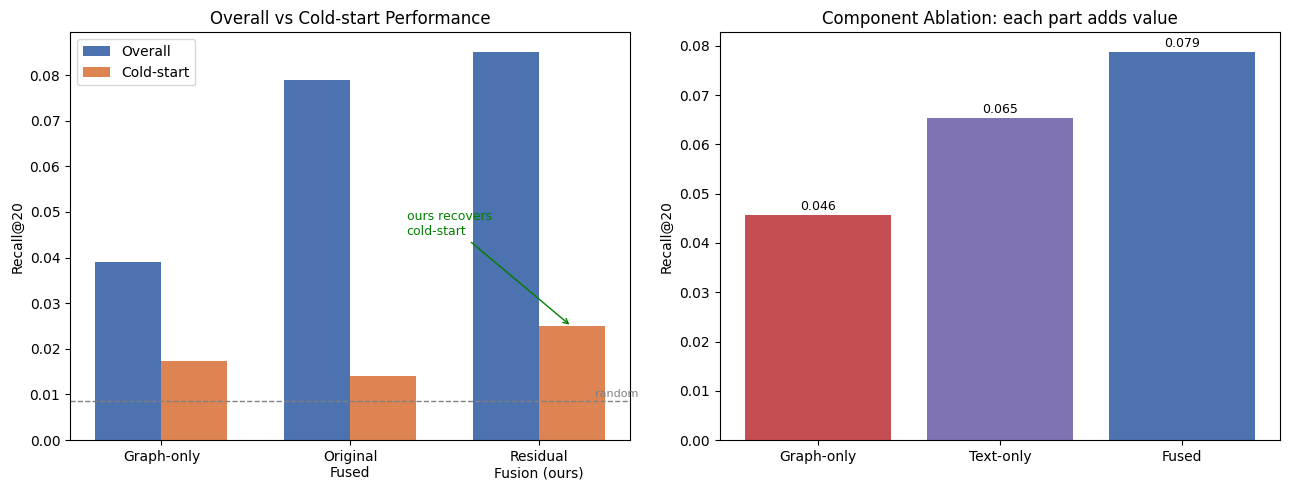

saved results_plots.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Plot 1: headline — overall vs cold-start ----
models = ["Graph-only", "Original\nFused", "Residual\nFusion (ours)"]
overall_scores = [0.0390, 0.0788, 0.0851]
cold_scores    = [0.0174, 0.0141, 0.0249]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(models)); w = 0.35
ax = axes[0]
ax.bar(x - w/2, overall_scores, w, label="Overall", color="#4C72B0")
ax.bar(x + w/2, cold_scores,    w, label="Cold-start", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("Recall@20"); ax.set_title("Overall vs Cold-start Performance")
ax.legend()
ax.axhline(20/2351, ls="--", c="gray", lw=1)  # random baseline
ax.text(2.3, 20/2351 + 0.001, "random", color="gray", fontsize=8)
# highlight the win
ax.annotate("ours recovers\ncold-start", xy=(2+w/2, 0.0249), xytext=(1.3, 0.045),
            arrowprops=dict(arrowstyle="->", color="green"), color="green", fontsize=9)

# ---- Plot 2: baseline ablation ----
ax = axes[1]
abl_models = ["Graph-only", "Text-only", "Fused"]
abl_scores = [0.0456, 0.0654, 0.0788]
bars = ax.bar(abl_models, abl_scores, color=["#C44E52", "#8172B3", "#4C72B0"])
ax.set_ylabel("Recall@20"); ax.set_title("Component Ablation: each part adds value")
for b, s in zip(bars, abl_scores):
    ax.text(b.get_x()+b.get_width()/2, s+0.001, f"{s:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/results_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved results_plots.png")

tagged 1716 of 2351 products for the plot


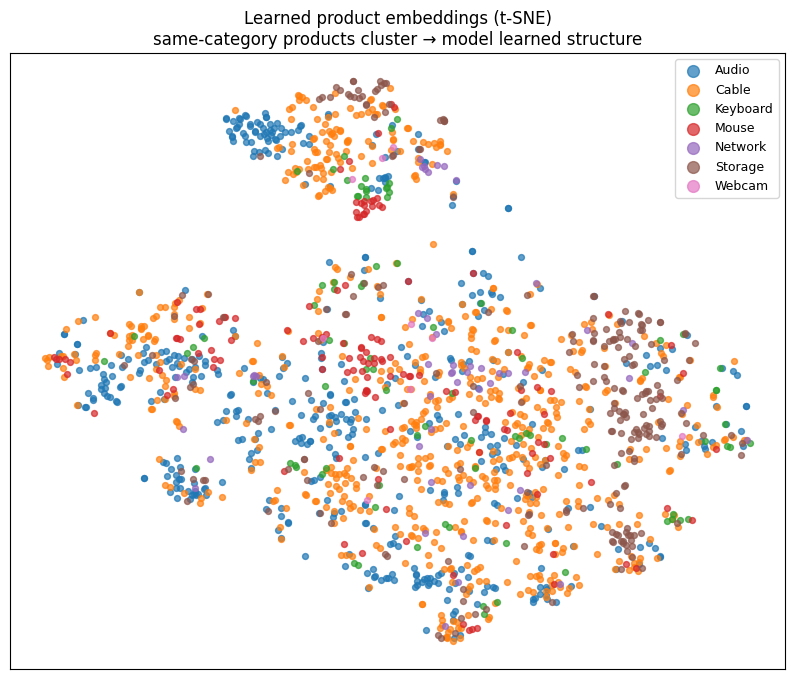

saved embedding_map.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. get final learned embeddings from your best model
with torch.no_grad():
    final_emb = model_res(data.x, train_edge_index).cpu().numpy()

# 2. crude category tagging by keyword in the product text (for coloring only)
categories = {
    "mouse": "Mouse", "keyboard": "Keyboard", "ssd": "Storage", "nvme": "Storage",
    "flash drive": "Storage", "microsd": "Storage", "headphone": "Audio",
    "headset": "Audio", "speaker": "Audio", "earbud": "Audio", "cable": "Cable",
    "adapter": "Cable", "hdmi": "Cable", "webcam": "Webcam", "router": "Network",
    "wireless adapter": "Network",
}
def tag(text):
    t = text.lower()
    for kw, label in categories.items():
        if kw in t:
            return label
    return "Other"

labels = np.array([tag(texts[i]) for i in range(len(texts))])

# 3. t-SNE to 2D (only on tagged points, so clusters are visible; skip 'Other')
mask = labels != "Other"
print(f"tagged {mask.sum()} of {len(labels)} products for the plot")

emb2d = TSNE(n_components=2, perplexity=30, random_state=42,
             init="pca").fit_transform(final_emb[mask])

# 4. plot
plt.figure(figsize=(10, 8))
sub_labels = labels[mask]
for cat in sorted(set(sub_labels)):
    pts = emb2d[sub_labels == cat]
    plt.scatter(pts[:, 0], pts[:, 1], label=cat, s=18, alpha=0.7)
plt.legend(markerscale=2, fontsize=9)
plt.title("Learned product embeddings (t-SNE)\nsame-category products cluster → model learned structure")
plt.xticks([]); plt.yticks([])
plt.savefig(f"{SAVE_DIR}/embedding_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved embedding_map.png")

tagged 970 products across 5 clean categories


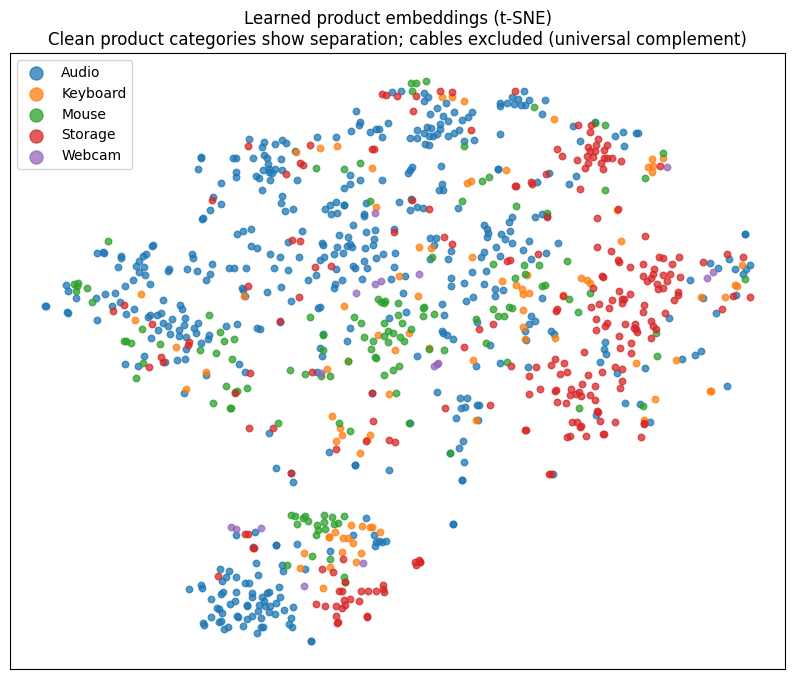

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# cleaner category set — drop the noisy "cable/adapter" universal-complement class
categories = {
    "mouse": "Mouse", "keyboard": "Keyboard",
    "ssd": "Storage", "nvme": "Storage", "flash drive": "Storage", "microsd": "Storage",
    "headphone": "Audio", "headset": "Audio", "earbud": "Audio", "speaker": "Audio",
    "webcam": "Webcam",
}
def tag(text):
    t = text.lower()
    for kw, label in categories.items():
        if kw in t:
            return label
    return "Other"

labels = np.array([tag(texts[i]) for i in range(len(texts))])
mask = labels != "Other"
print(f"tagged {mask.sum()} products across {len(set(labels[mask]))} clean categories")

emb2d = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(final_emb[mask])

plt.figure(figsize=(10, 8))
sub = labels[mask]
for cat in sorted(set(sub)):
    pts = emb2d[sub == cat]
    plt.scatter(pts[:, 0], pts[:, 1], label=cat, s=22, alpha=0.75)
plt.legend(markerscale=2, fontsize=10)
plt.title("Learned product embeddings (t-SNE)\nClean product categories show separation; cables excluded (universal complement)")
plt.xticks([]); plt.yticks([])
plt.savefig(f"{SAVE_DIR}/embedding_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
!pip install -q gradio

In [ ]:
import torch
import torch.nn.functional as F

# --- precompute the two pathways separately for explainability ---
model_res.eval()
with torch.no_grad():
    x = data.x
    # graph pathway (the conv layers)
    h = model_res.dropout(F.relu(model_res.conv1(x, train_edge_index)))
    h = model_res.conv2(h, train_edge_index)
    # text pathway (the skip connection)
    t = model_res.text_proj(x)
    # full (what we actually rank with)
    full = F.normalize(h + t, dim=-1)
    h_n = F.normalize(h, dim=-1)
    t_n = F.normalize(t, dim=-1)

h_n, t_n, full = h_n.cpu(), t_n.cpu(), full.cpu()
print("pathways cached:", full.shape)

def recommend_with_explanation(query_idx, topk=8):
    scores = full[query_idx] @ full.T
    scores[query_idx] = -float('inf')
    top = torch.argsort(scores, descending=True)[:topk].tolist()

    results = []
    for t_idx in top:
        # decompose: how much from text path vs graph path?
        text_c  = (t_n[query_idx] @ t_n[t_idx]).item()
        graph_c = (h_n[query_idx] @ h_n[t_idx]).item()
        total = abs(text_c) + abs(graph_c) + 1e-9
        text_pct  = 100 * abs(text_c) / total
        graph_pct = 100 * abs(graph_c) / total
        results.append({
            "title": texts[t_idx][:70],
            "score": scores[t_idx].item(),
            "text_pct": text_pct,
            "graph_pct": graph_pct,
        })
    return results

# quick test
for r in recommend_with_explanation(1000, topk=3):
    print(f"{r['title']}\n   text {r['text_pct']:.0f}% | graph {r['graph_pct']:.0f}%\n")

pathways cached: torch.Size([2351, 128])
Logitech Illuminated Ultrathin Keyboard K740 with Laser-Etched Backlit
   text 51% | graph 49%

Logitech B100 Corded Mouse, Wired USB Mouse for Computers and Laptops,
   text 51% | graph 49%

Logitech Z130 3.5mm Jack Compact Laptop Speakers + Logitech Bluetooth 
   text 52% | graph 48%



In [ ]:
import gradio as gr

# ---- searchable product list ----
choices = [(f"{texts[i][:60]}", i) for i in range(len(texts))]

# ---- colored HTML bar (renders properly on Gradio's dark theme) ----
def bar_html(pct, color):
    width = max(2, int(pct * 1.6))   # scale: 100% -> 160px
    return (f"<span style='display:inline-block;background:{color};"
            f"width:{width}px;height:11px;border-radius:3px;"
            f"vertical-align:middle;margin-left:6px'></span>")

def demo_fn(selected_idx):
    if selected_idx is None:
        return "Pick a product above."
    recs = recommend_with_explanation(selected_idx, topk=8)
    out  = (f"### Because you viewed:\n"
            f"**{texts[selected_idx][:90]}**\n\n---\n"
            f"### Recommended products\n\n")
    for i, r in enumerate(recs, 1):
        out += (
            f"**{i}. {r['title']}**  \n"
            f"&nbsp;&nbsp;similarity&nbsp;**{r['score']:.3f}**  \n"
            f"&nbsp;&nbsp;📝 text&nbsp;{r['text_pct']:.0f}% "
            f"{bar_html(r['text_pct'], '#4C72B0')}  \n"
            f"&nbsp;&nbsp;🔗 co-purchase&nbsp;{r['graph_pct']:.0f}% "
            f"{bar_html(r['graph_pct'], '#DD8452')}\n\n"
        )
    return out

with gr.Blocks(title="Hybrid Product Recommender") as demo:
    gr.Markdown(
        "# 🛒 Hybrid GNN + Transformer Product Recommender\n"
        "Recommends products by combining a **co-purchase graph** (GNN) with "
        "**product-text understanding** (BERT). Each result shows *why* it was "
        "suggested — how much came from textual similarity vs. co-purchase behavior.\n\n"
        "*Note: the split shows which signal leaned heavier, not a hard causal split.*"
    )
    dropdown = gr.Dropdown(choices=choices, label="Select a product",
                           filterable=True, value=1000)
    btn = gr.Button("Get Recommendations", variant="primary")
    output = gr.Markdown()
    btn.click(demo_fn, inputs=dropdown, outputs=output)
    # also fire on selection change, so it updates without clicking
    dropdown.change(demo_fn, inputs=dropdown, outputs=output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://974d9ecf972824dc16.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
torch.save(model_graph.state_dict(), f"{SAVE_DIR}/graph_only_model.pt")
torch.save(random_x.cpu(), f"{SAVE_DIR}/random_x.pt")
print("baseline pieces saved — everything is now on Drive")
import os
for fn in sorted(os.listdir(SAVE_DIR)):
    print(" ", fn)

baseline pieces saved — everything is now on Drive
  embedding_map.png
  fused_model.pt
  graph_data.pt
  graph_only_model.pt
  meta.pkl
  random_x.pt
  residual_fusion_model.pt
  results_plots.png


In [ ]:
# ===== RESUME =====
!pip install -q torch_geometric sentence-transformers gradio

import torch, pickle, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from google.colab import drive

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/gnn_recsys"
device = "cuda" if torch.cuda.is_available() else "cpu"

data = torch.load(f"{SAVE_DIR}/graph_data.pt", weights_only=False).to(device)
with open(f"{SAVE_DIR}/meta.pkl", "rb") as f:
    meta = pickle.load(f)
item2idx, idx2item, texts, core = (meta["item2idx"], meta["idx2item"],
                                   meta["texts"], meta["core_reviews"])

class ResidualFusionGNN(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)
        self.text_proj = nn.Linear(in_dim, out_dim)
    def forward(self, x, edge_index):
        h = self.dropout(F.relu(self.conv1(x, edge_index)))
        h = self.conv2(h, edge_index)
        return h + self.text_proj(x)

model_res = ResidualFusionGNN().to(device)
model_res.load_state_dict(torch.load(f"{SAVE_DIR}/residual_fusion_model.pt"))
model_res.eval()
print("resumed ✓", data)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00
Mounted at /content/drive
resumed ✓ Data(x=[2351, 384], edge_index=[2, 19284], edge_weight=[19284])


In [ ]:
import os, shutil

SPACE_DIR = "/content/space"
os.makedirs(SPACE_DIR, exist_ok=True)

for fn in ["graph_data.pt", "meta.pkl", "residual_fusion_model.pt"]:
    shutil.copy(f"{SAVE_DIR}/{fn}", f"{SPACE_DIR}/{fn}")

with open(f"{SPACE_DIR}/requirements.txt", "w") as f:
    f.write("torch\ntorch_geometric\nsentence-transformers\ngradio\n")

print("staged:", os.listdir(SPACE_DIR))

staged: ['meta.pkl', 'graph_data.pt', 'requirements.txt', 'residual_fusion_model.pt']


In [ ]:
app_code = '''
import torch, pickle, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import gradio as gr

device = "cpu"   # HF free tier is CPU; our model is tiny so this is fine

# --- model definition (must match what we trained) ---
class ResidualFusionGNN(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.3)
        self.text_proj = nn.Linear(in_dim, out_dim)
    def forward(self, x, edge_index):
        h = self.dropout(F.relu(self.conv1(x, edge_index)))
        h = self.conv2(h, edge_index)
        return h + self.text_proj(x)

# --- load artifacts ---
data = torch.load("graph_data.pt", weights_only=False, map_location=device)
with open("meta.pkl", "rb") as f:
    meta = pickle.load(f)
texts = meta["texts"]

model = ResidualFusionGNN().to(device)
model.load_state_dict(torch.load("residual_fusion_model.pt", map_location=device))
model.eval()

# --- precompute the two pathways for explainability ---
with torch.no_grad():
    x, ei = data.x.to(device), data.edge_index.to(device)
    h = model.dropout(F.relu(model.conv1(x, ei)))
    h = model.conv2(h, ei)
    t = model.text_proj(x)
    full = F.normalize(h + t, dim=-1)
    h_n = F.normalize(h, dim=-1)
    t_n = F.normalize(t, dim=-1)

def recommend(query_idx, topk=8):
    scores = full[query_idx] @ full.T
    scores[query_idx] = -float("inf")
    top = torch.argsort(scores, descending=True)[:topk].tolist()
    out = []
    for ti in top:
        tc = abs((t_n[query_idx] @ t_n[ti]).item())
        gc = abs((h_n[query_idx] @ h_n[ti]).item())
        tot = tc + gc + 1e-9
        out.append((texts[ti][:70], scores[ti].item(),
                    100*tc/tot, 100*gc/tot))
    return out

def bar(pct, color):
    w = max(2, int(pct * 1.6))
    return (f"<span style='display:inline-block;background:{color};width:{w}px;"
            f"height:11px;border-radius:3px;vertical-align:middle;margin-left:6px'></span>")

choices = [(texts[i][:60], i) for i in range(len(texts))]

def demo_fn(idx):
    if idx is None:
        return "Pick a product."
    recs = recommend(idx)
    out = f"### Because you viewed:\\n**{texts[idx][:90]}**\\n\\n---\\n### Recommended\\n\\n"
    for i,(title,sc,tp,gp) in enumerate(recs,1):
        out += (f"**{i}. {title}**  \\n&nbsp;&nbsp;similarity **{sc:.3f}**  \\n"
                f"&nbsp;&nbsp;📝 text {tp:.0f}% {bar(tp,'#4C72B0')}  \\n"
                f"&nbsp;&nbsp;🔗 co-purchase {gp:.0f}% {bar(gp,'#DD8452')}\\n\\n")
    return out

with gr.Blocks(title="Hybrid Product Recommender") as demo:
    gr.Markdown("# 🛒 Hybrid GNN + Transformer Product Recommender\\n"
                "Combines a **co-purchase graph** (GNN) with **product text** (BERT). "
                "Each result shows which signal drove it.\\n\\n"
                "*Split shows which signal leaned heavier, not a hard causal split.*")
    dd = gr.Dropdown(choices=choices, label="Select a product", filterable=True, value=1000)
    dd.change(demo_fn, inputs=dd, outputs=gr.Markdown())
    btn = gr.Button("Get Recommendations", variant="primary")
    out = gr.Markdown()
    btn.click(demo_fn, inputs=dd, outputs=out)

demo.launch()
'''
with open(f"{SPACE_DIR}/app.py", "w") as f:
    f.write(app_code)
print("app.py written. Files:", os.listdir(SPACE_DIR))

app.py written. Files: ['meta.pkl', 'graph_data.pt', 'app.py', 'requirements.txt', 'residual_fusion_model.pt']


In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

In [ ]:
from huggingface_hub import create_repo, upload_folder, whoami

username = whoami()["name"]
print("logged in as:", username)

space_id = f"{username}/hybrid-product-recommender"

# create the Space
create_repo(space_id, repo_type="space", space_sdk="gradio", exist_ok=True)
print("space created:", space_id)

# upload all five files
upload_folder(
    repo_id=space_id,
    repo_type="space",
    folder_path="/content/space",
)
print(f"\n✅ uploaded! Space building at:")
print(f"   https://huggingface.co/spaces/{space_id}")

logged in as: rudranil7
space created: rudranil7/hybrid-product-recommender


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../residual_fusion_model.pt:   7%|6         | 82.7kB / 1.25MB            

  /content/space/graph_data.pt:   7%|6         |  264kB / 4.00MB            

  /content/space/meta.pkl     :   7%|6         |  308kB / 4.65MB            


✅ uploaded! Space building at:
   https://huggingface.co/spaces/rudranil7/hybrid-product-recommender
